<a href="https://colab.research.google.com/github/teguhsmlnna666/Teguh-Esa-Maulanna_2411532005_ML2526/blob/main/Praktikum9/Bagging%26RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

acc_tree_train = accuracy_score(y_train, tree.predict(X_train))
acc_tree_test = accuracy_score(y_test, tree.predict(X_test))

print("Decision Tree Train:", acc_tree_train)
print("Decision Tree Test :", acc_tree_test)

Decision Tree Train: 1.0
Decision Tree Test : 0.9473684210526315


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train:", acc_rf_train)
print("Random Forest Test :", acc_rf_test)

Random Forest Train: 1.0
Random Forest Test : 0.9649122807017544


In [9]:
importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance.head)

<bound method NDFrame.head of                     Feature  Importance
23               worst area    0.153892
27     worst concave points    0.144663
7       mean concave points    0.106210
20             worst radius    0.077987
6            mean concavity    0.068001
22          worst perimeter    0.067115
2            mean perimeter    0.053270
0               mean radius    0.048703
3                 mean area    0.047555
26          worst concavity    0.031802
13               area error    0.022407
21            worst texture    0.021749
25        worst compactness    0.020266
10             radius error    0.020139
5          mean compactness    0.013944
1              mean texture    0.013591
12          perimeter error    0.011303
24         worst smoothness    0.010644
28           worst symmetry    0.010120
16          concavity error    0.009386
4           mean smoothness    0.007285
19  fractal dimension error    0.005321
15        compactness error    0.005253
29  worst 

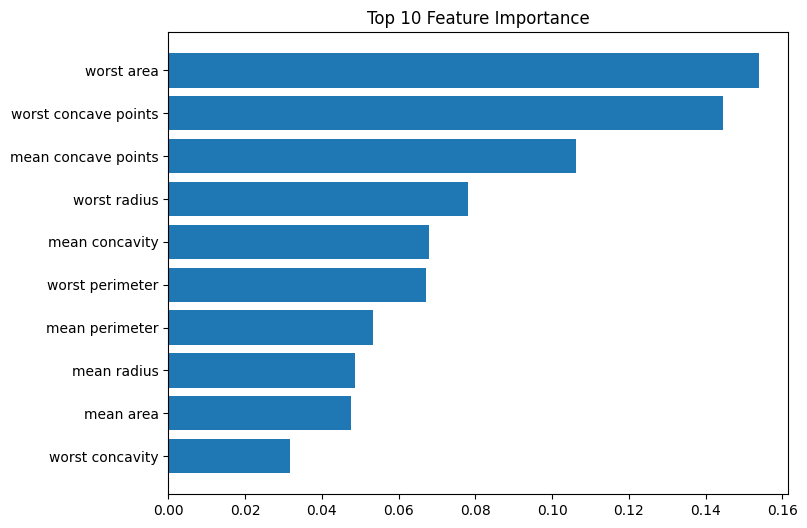

In [6]:
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"][:10],
         feat_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

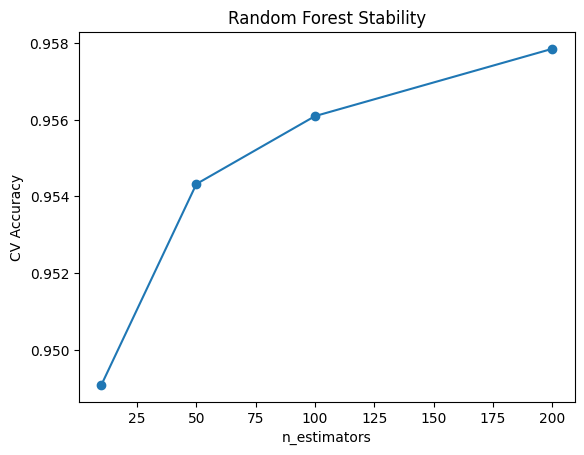

In [7]:
estimators = [10, 50, 100, 200]
rf_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores.append(score)

plt.plot(estimators, rf_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability")
plt.show()

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
score_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=5).mean()

score_rf = cross_val_score(rf, X, y, cv=5).mean()

print("RF tanpa PCA:", score_rf)
print("RF dengan PCA:", score_rf_pca)

RF tanpa PCA: 0.9560937742586555
RF dengan PCA: 0.9507529886663562


Tugas Individu

In [14]:
# Uji max_depth berbeda pada Random Forest.

max_depth_list = [None, 3, 5, 7, 10]

for depth in max_depth_list:
    rf_depth = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    score = cross_val_score(
        rf_depth,
        X,
        y,
        cv=5
    ).mean()

    print(f"RF max_depth={depth}: {score}")

RF max_depth=None: 0.9560937742586555
RF max_depth=3: 0.9543238627542309
RF max_depth=5: 0.9596180717279925
RF max_depth=7: 0.9543083372147182
RF max_depth=10: 0.9560937742586555


In [15]:
# Tambahkan parameter max_features dan min_samples_leaf

max_features_list = ["sqrt", "log2"]
min_samples_leaf_list = [1, 2, 4, 6]

hasil = []

for mf in max_features_list:
    for leaf in min_samples_leaf_list:

        rf = RandomForestClassifier(
            n_estimators=100,
            max_features=mf,
            min_samples_leaf=leaf,
            random_state=42
        )

        score = cross_val_score(
            rf,
            X,
            y,
            cv=5
        ).mean()

        hasil.append([
            mf,
            leaf,
            score
        ])

tabel_hasil = pd.DataFrame(
    hasil,
    columns=[
        "max_features",
        "min_samples_leaf",
        "CV Accuracy"
    ]
)

tabel_hasil.round(4)

,max_features,min_samples_leaf,CV Accuracy
0,sqrt,1,0.9561
1,sqrt,2,0.9578
2,sqrt,4,0.9596
3,sqrt,6,0.9579
4,log2,1,0.9596
5,log2,2,0.9614
6,log2,4,0.9578
7,log2,6,0.9543


In [17]:
# Bandingkan dengan Logistic Regression.

from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

logreg = LogisticRegression(max_iter=5000)

score_logreg = cross_val_score(
    logreg,
    X_scaled,
    y,
    cv=5
).mean()

score_rf = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    X,
    y,
    cv=5
).mean()

print("Logistic Regression:", score_logreg)
print("Random Forest      :", score_rf)

Logistic Regression: 0.9806862288464524
Random Forest      : 0.9560937742586555


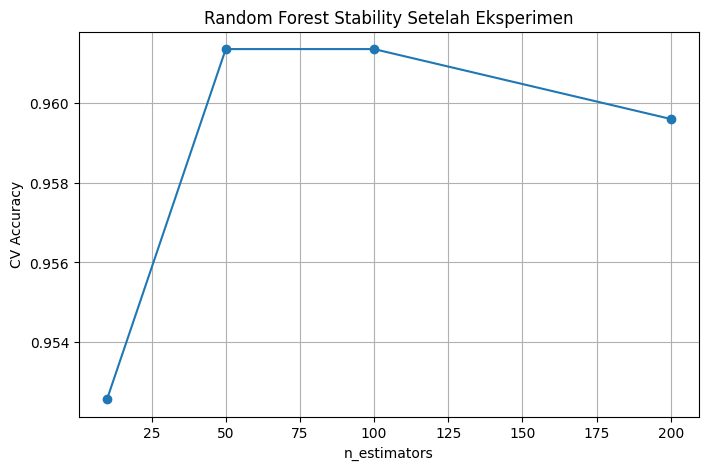

In [22]:
# Grafik stability

estimators = [10, 50, 100, 200]
rf_scores_best = []

for n in estimators:
    rf_best_stability = RandomForestClassifier(
        n_estimators=n,
        max_features="log2",
        min_samples_leaf=2,
        random_state=42
    )

    score = cross_val_score(
        rf_best_stability,
        X,
        y,
        cv=5
    ).mean()

    rf_scores_best.append(score)

plt.figure(figsize=(8,5))
plt.plot(estimators, rf_scores_best, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability Setelah Eksperimen")
plt.grid(True)
plt.show()

In [23]:
# feature importance

rf_best = RandomForestClassifier(
    n_estimators=100,
    max_features="log2",
    min_samples_leaf=2,
    random_state=42
)

rf_best.fit(X_train, y_train)

importances_best = rf_best.feature_importances_

feat_importance_best = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances_best
}).sort_values(by="Importance", ascending=False)

print(feat_importance_best.head(10))

                 Feature  Importance
27  worst concave points    0.134959
23            worst area    0.121353
20          worst radius    0.089737
6         mean concavity    0.084158
7    mean concave points    0.080055
2         mean perimeter    0.079939
22       worst perimeter    0.060775
3              mean area    0.052250
0            mean radius    0.050855
13            area error    0.034579


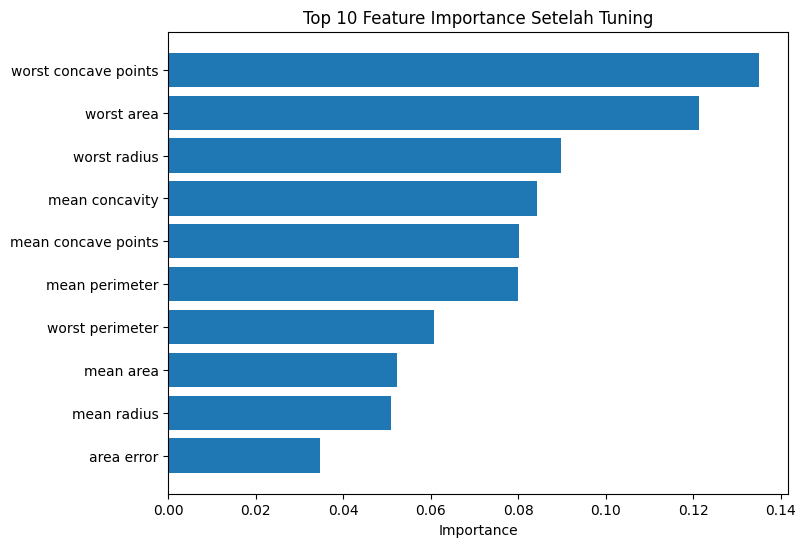

In [25]:
# visualisasi fitur importance

plt.figure(figsize=(8,6))

plt.barh(
    feat_importance_best["Feature"][:10],
    feat_importance_best["Importance"][:10]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance Setelah Tuning")
plt.show()